# Tutorial 01 | Regulatory archetypes from Paul15 hematopoiesis

Demonstrates the core scJDO workflow on the Paul15 dataset:
progenitor → erythroid / neutrophil bifurcation.

| Step | Call | Output |
|------|------|--------|
| Preprocess | `sjd.pp.prepare_trajectory` | normalized adata + pseudotime |
| Fit | `sjd.tl.fit_drift` | Jacobian tensor + archetypes in `adata.uns` |
| Plot | `sjd.pl.*` | drift field, sensitivity, archetypes, coordination |

In [38]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import scanpy as sc
import scjdo as sjd

# ── Configuration ──────────────────────────────────────────────────────────
N_ARCHETYPES = 5
N_EPOCHS     = 5000     # increase to 50,000 + GPU for publication quality
OUTDIR       = 'results/01_paul15/'
os.makedirs(OUTDIR, exist_ok=True)

print(f'scjdo v{sjd.__version__}')

scjdo v0.3.0


## 1. Load data

In [39]:
adata = sc.datasets.paul15()
REMOVE_CLUSTERS = ['19Lymph', '11DC']

keep_mask = ~adata.obs['paul15_clusters'].isin(REMOVE_CLUSTERS)

adata = adata[keep_mask].copy()
# Identify ribosomal genes
ribo_mask = adata.var_names.str.startswith(("Rps", "Rpl", "RPS", "RPL"))

# Remove them
adata = adata[:, ~ribo_mask].copy()
print(adata)

Task was destroyed but it is pending!
task: <Task pending name='Task-549' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /Users/terooatt/miniconda3/envs/scJDO/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-550' coro=<_async_in_context.<locals>.preserve_context() running at /Users/terooatt/miniconda3/envs/scJDO/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/terooatt/miniconda3/envs/scJDO/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/terooatt/miniconda3/envs/scJDO/lib/python3.10/site-packages/pandas/_config/config.py:480: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  self.undo = [(pat, _get_option(pat)) for pat, val in self.ops]
Task was destroyed but it is pending!
task: <Task pending name='Task-550' coro=<_async_in_context.<locals>.preserve_context() running at /Us

AnnData object with n_obs × n_vars = 2669 × 3429
    obs: 'paul15_clusters'
    uns: 'iroot'


## 2. Preprocess

One call: normalize → HVG (2000) → PCA (50) → kNN graph → DPT pseudotime rooted at 7MEP.

[pseudotime] DPT: root=7MEP, range=[0, 1]


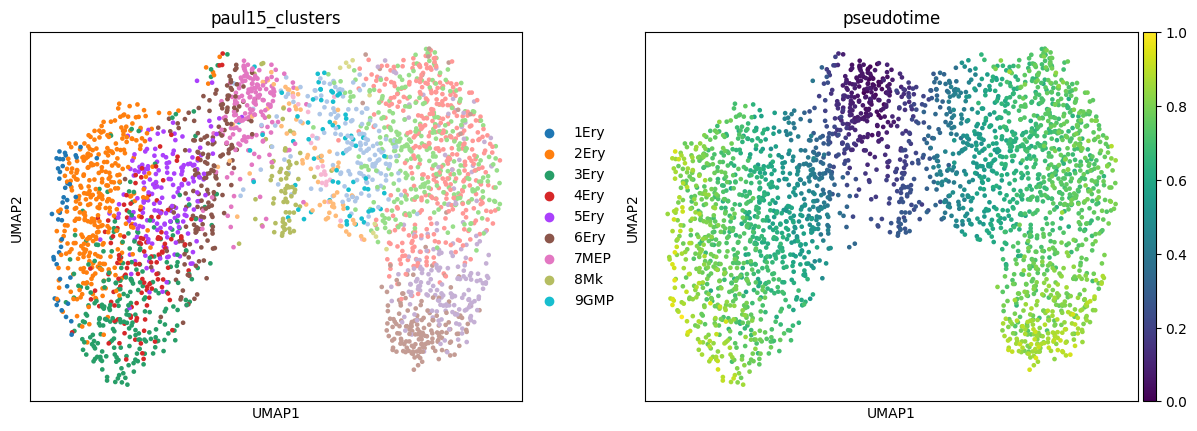

Pseudotime range: [0.000, 1.000]


In [40]:
sjd.pp.prepare_trajectory(
    adata,
    groupby = 'paul15_clusters',
    root    = '7MEP',
    n_hvg   = 2000,
    n_pcs   = 50,
)

# Quick QC check
sc.pl.umap(adata, color=['paul15_clusters', 'pseudotime'], ncols=2)
print(f"Pseudotime range: [{adata.obs['pseudotime'].min():.3f}, {adata.obs['pseudotime'].max():.3f}]")

## 3. Fit drift field and compute archetypes

Trains the drift model, builds the Jacobian tensor (100 windows), and runs semi-NMF decomposition. Pseudotime-gradient velocity is derived automatically — no RNA velocity needed.

In [41]:
sjd.tl.fit_drift(
    adata,
    time_key     = 'pseudotime',
    n_archetypes = N_ARCHETYPES,
    n_epochs     = N_EPOCHS,
    vel_scale    = 2.0,
)

print(f"R² = {adata.uns['scjdo']['r2']:.3f}")

[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 99.3761
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.993 | Archetypes stored in adata.uns['scjdo']
R² = 0.993


## 4. Figure 3 — four-panel summary

Saved: results/01_paul15/figure3.pdf


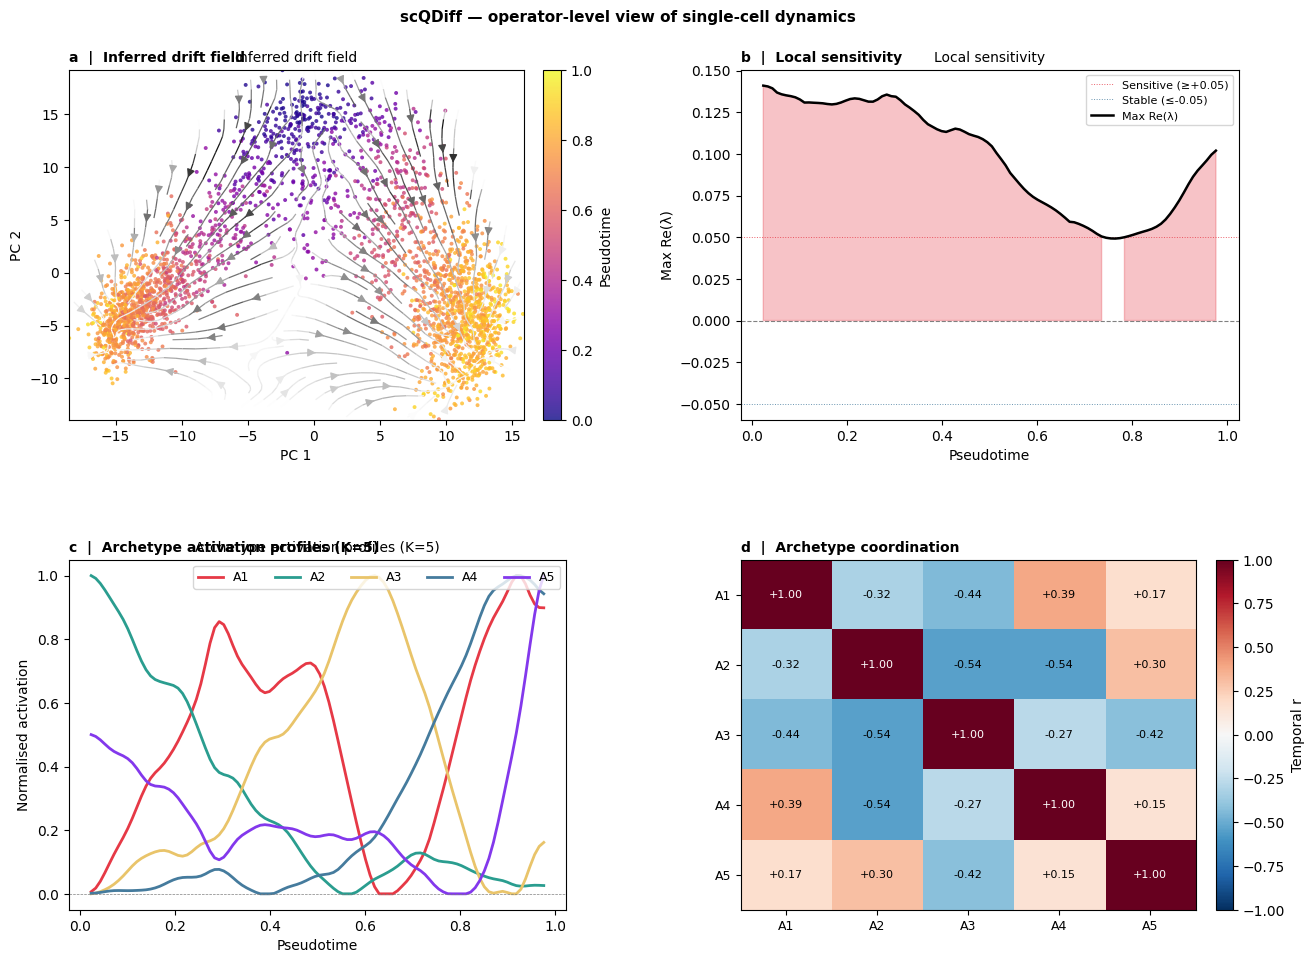

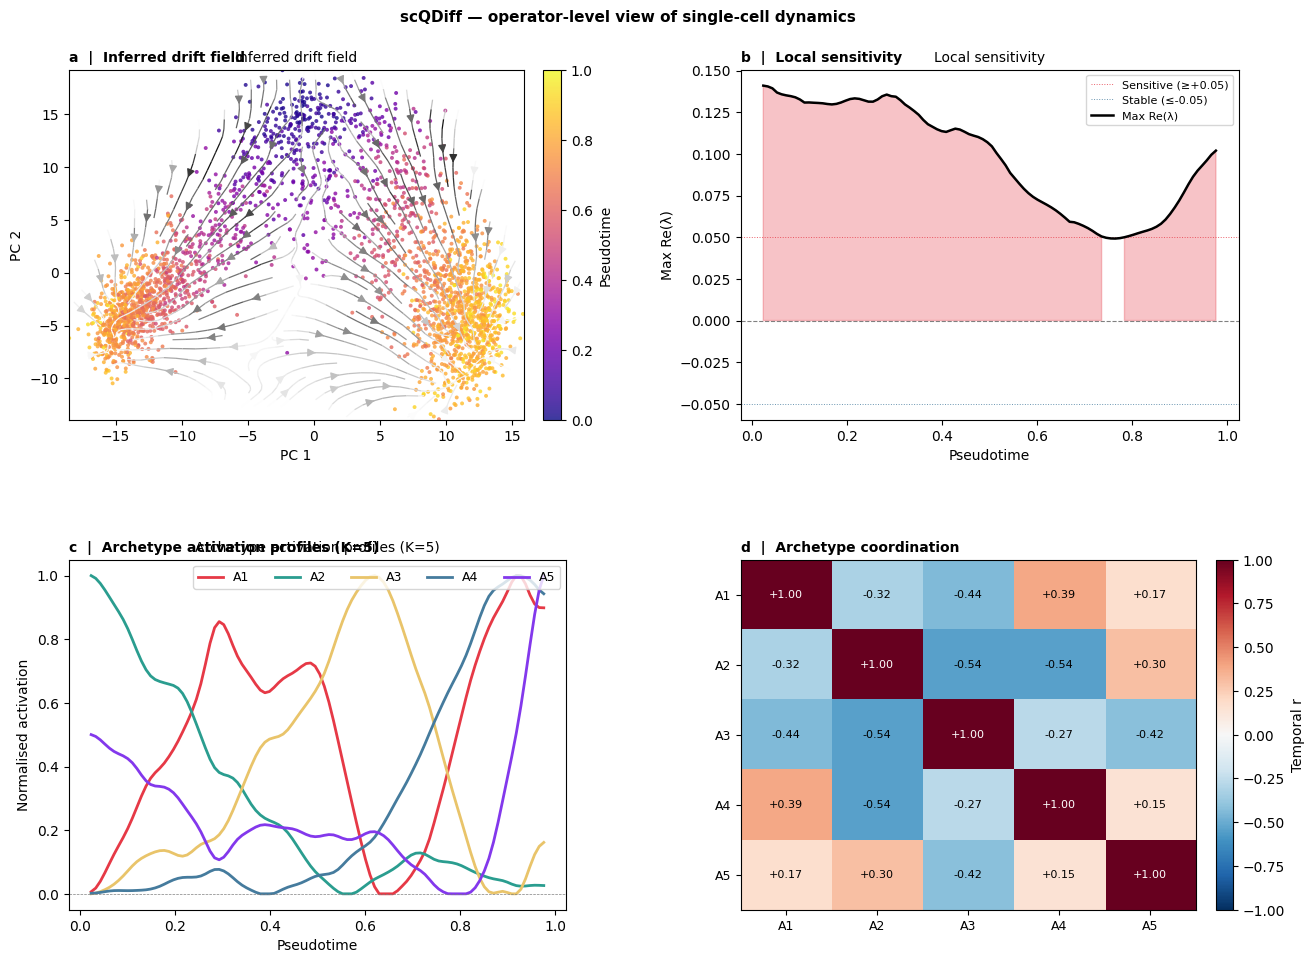

In [28]:
sjd.pl.summary_figure(adata, basis='X_pca', save=OUTDIR + 'figure3.pdf')

## 5. Individual panels

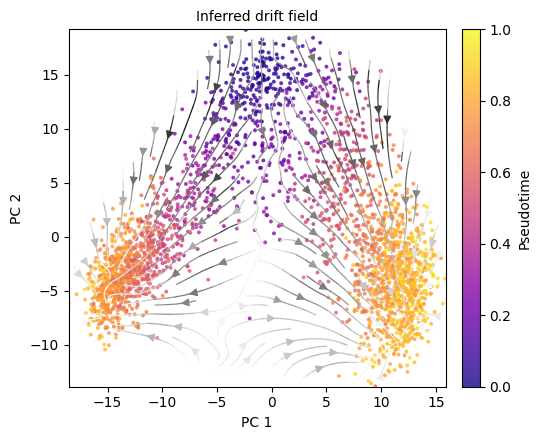

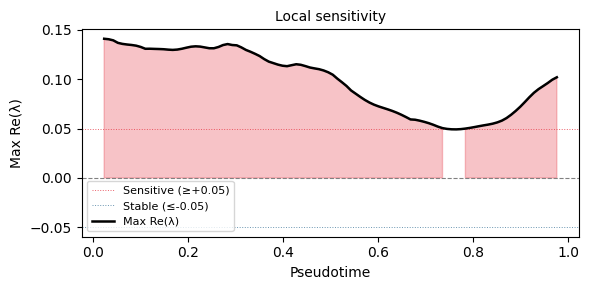

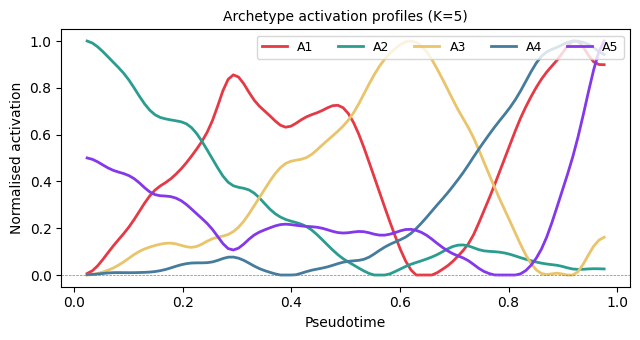

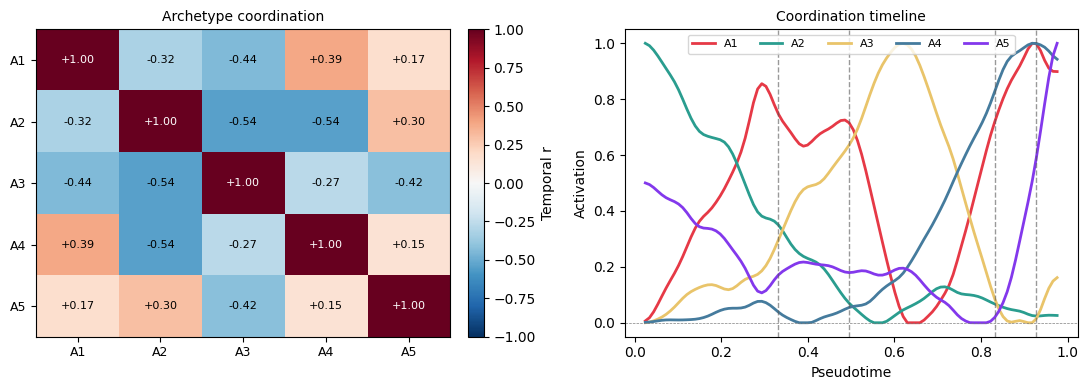

(<Axes: title={'center': 'Archetype coordination'}>,
 <Axes: title={'center': 'Coordination timeline'}, xlabel='Pseudotime', ylabel='Activation'>)

In [29]:
sjd.pl.drift_field(adata, basis='X_pca',   save=OUTDIR + 'drift_field.pdf')
sjd.pl.sensitivity(adata,                   save=OUTDIR + 'sensitivity.pdf')
sjd.pl.archetypes(adata,                    save=OUTDIR + 'archetypes.pdf')
sjd.pl.coordination(adata,                  save=OUTDIR + 'coordination.pdf')

## 6. Gene-level results

Locally sensitive genes per archetype — these are candidates for perturbation experiments.

In [30]:
import numpy as np

res = adata.uns['scjdo']
print(f"Peak sensitivity at pseudotime: {res['t_centers'][np.argmax(res['max_real_eig'])]:.3f}\n")

print("Top 10 locally sensitive genes per archetype:")
for k in range(N_ARCHETYPES):
    genes = res['top_genes'].get(str(k), [])[:10]
    print(f"  A{k+1}: {', '.join(genes)}")

Peak sensitivity at pseudotime: 0.024

Top 10 locally sensitive genes per archetype:
  A1: Cnn2, Ly6c2, Ptpn18, Vim, Creg1, Brd3, Myc, Prtn3, H2afy, Gng12
  A2: Sfpq, Pak1, H2-Q7, Snx3, Serp1, Klf13, Myc, Tagln2, Ssr4, Npc2
  A3: Rbm39, Capzb, Gltscr2, Dek, Spn, Rhog, Slc3a2, Dcaf8, Nme2, Cpsf2
  A4: Ctsg, Prtn3, Car1, Mt2, Car2, Malat1, Lgals1, Coro1a, Elane, Pkm2
  A5: Myc, Tuba1b, Fam65a, Myb, Ly6c2, Tmem176b, H2afy, Psmb8, Gpr56, Apoe


## 7. Key hematopoiesis regulators — where do they rank?

In [31]:
KEY_GENES = ['Gata1', 'Gata2', 'Spi1', 'Klf1', 'Mpo', 'Elane']
gene_names = list(adata.var_names)

for g in KEY_GENES:
    if g not in gene_names:
        continue
    gi = gene_names.index(g)
    for k in range(N_ARCHETYPES):
        gs = res['gene_scores'].get(str(k))
        if gs is None:
            continue
        import numpy as np
        rank = int(np.where(np.argsort(np.abs(gs))[::-1] == gi)[0][0]) + 1
        pct  = 100.0 * rank / len(gene_names)
        if pct < 20:   # only show if in top 20%
            print(f"  A{k+1} | {g}: rank {rank}/{len(gene_names)}  (top {pct:.1f}%)")

  A1 | Gata1: rank 356/2000  (top 17.8%)
  A2 | Gata1: rank 297/2000  (top 14.8%)
  A3 | Gata1: rank 87/2000  (top 4.3%)
  A4 | Gata1: rank 86/2000  (top 4.3%)
  A1 | Gata2: rank 42/2000  (top 2.1%)
  A5 | Gata2: rank 12/2000  (top 0.6%)
  A1 | Klf1: rank 366/2000  (top 18.3%)
  A4 | Klf1: rank 15/2000  (top 0.8%)
  A1 | Mpo: rank 53/2000  (top 2.6%)
  A3 | Mpo: rank 222/2000  (top 11.1%)
  A4 | Mpo: rank 13/2000  (top 0.7%)
  A5 | Mpo: rank 32/2000  (top 1.6%)
  A1 | Elane: rank 43/2000  (top 2.1%)
  A2 | Elane: rank 60/2000  (top 3.0%)
  A3 | Elane: rank 12/2000  (top 0.6%)
  A4 | Elane: rank 9/2000  (top 0.5%)


## 8. Save

In [32]:
import scanpy as sc
adata.write_h5ad(OUTDIR + 'paul15_scjdo.h5ad')
print(f"Saved to {OUTDIR}paul15_scjdo.h5ad")

Saved to results/01_paul15/paul15_scjdo.h5ad


## Instability Gene Analysis

Which genes drive local instability along the trajectory?

Projects the maximum-eigenvalue eigenvector of the local Jacobian at each sensitive pseudotime window into gene space. High-scoring genes are those whose perturbation is most amplified by the drift field — candidate drivers of fate decisions and perturbation targets.

**Outputs:** 3-panel figure (sensitivity curve, gene scores across pseudotime, per-archetype heatmap) + ranked CSV table.

/Users/terooatt/Downloads/scJDO/scjdo/pl/_drift.py:414: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


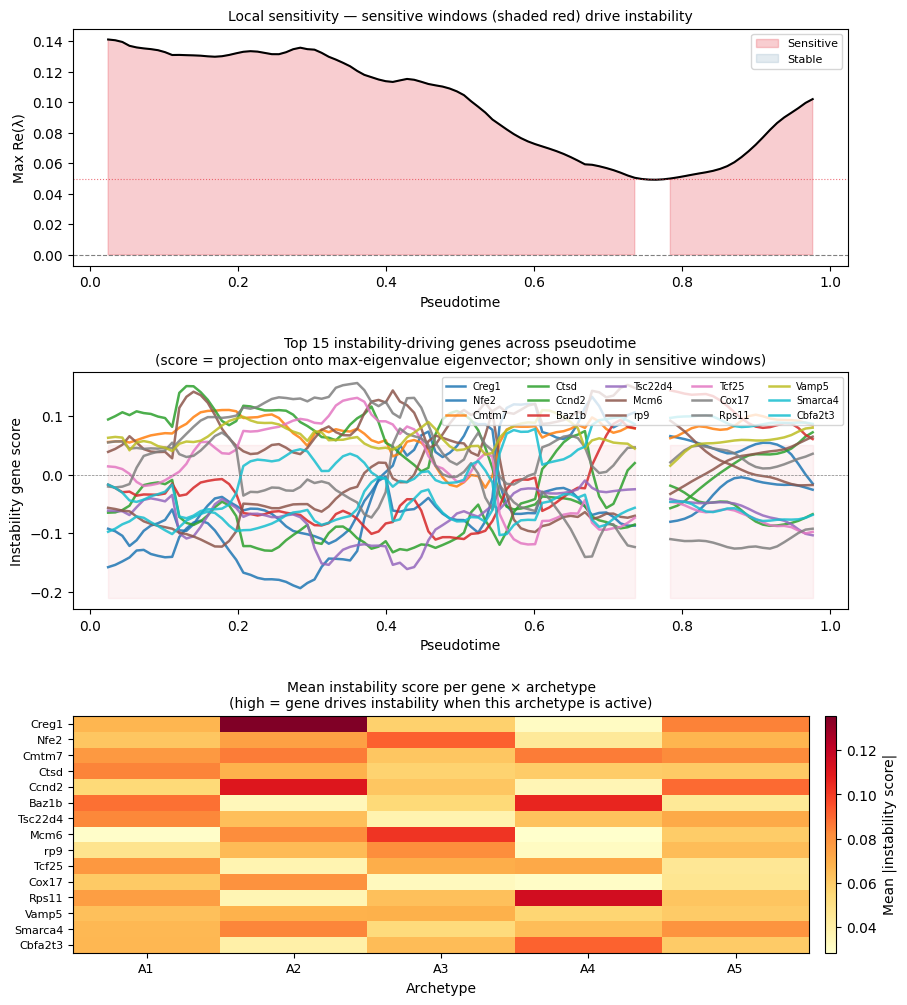

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1   Creg1                  0.0824            0.284                A1
    2    Nfe2                  0.0725            0.678                A3
    3   Cmtm7                  0.0717            0.188                A2
    4    Ctsd                  0.0716            0.409                A1
    5   Ccnd2                  0.0709            0.130                A2
    6   Baz1b                  0.0692            0.784                A4
    7 Tsc22d4                  0.0687            0.428                A1
    8    Mcm6                  0.0669            0.726                A3
    9     rp9                  0.0660            0.409                A1
   10   Tcf25                  0.0650            0.361                A1
   11   Cox17                  0.0642            0.361                A1
   12   Rps11                  0.0638            0.668                A3
   13   Vamp5                  0.0624            0.

In [33]:
table = sjd.pl.instability_genes(
    adata,
    n_genes               = 15,
    sensitivity_threshold = 0.05,
    per_archetype         = True,
    save = OUTDIR + 'instability_genes.pdf',
)

In [34]:
table.to_csv(OUTDIR + 'instability_genes_table.csv', index=False)
print(table.to_string(index=False))

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1   Creg1                  0.0824            0.284                A1
    2    Nfe2                  0.0725            0.678                A3
    3   Cmtm7                  0.0717            0.188                A2
    4    Ctsd                  0.0716            0.409                A1
    5   Ccnd2                  0.0709            0.130                A2
    6   Baz1b                  0.0692            0.784                A4
    7 Tsc22d4                  0.0687            0.428                A1
    8    Mcm6                  0.0669            0.726                A3
    9     rp9                  0.0660            0.409                A1
   10   Tcf25                  0.0650            0.361                A1
   11   Cox17                  0.0642            0.361                A1
   12   Rps11                  0.0638            0.668                A3
   13   Vamp5                  0.0624            0.

## Regulatory Network Inference

Links instability genes to upstream TF regulators using a signed TF-target network (CollecTRI → TRRUST → built-in). Scores each TF on six metrics:

| Metric | What it captures |
|--------|------------------|
| Weighted out-degree | Total instability explained by TF targets |
| Mean target instability | Quality: few sharp targets > many weak ones |
| Regulon enrichment | Hypergeometric overlap with top instability genes |
| Branch specificity | Entropy-based archetype preference |
| Database confidence | Mean edge weight in the source network |
| Pseudotime lead | TF expression peak before target instability peak |

**Figure 5 (hybrid network):** solid edges = database-confirmed links; dashed edges = de novo co-instability pairs inferred from Jacobian eigenvector structure.

In [35]:
# Infer upstream TF regulators
df_reg = sjd.tl.infer_regulators(
    adata,
    organism = 'mouse',
    min_targets = 3,
    n_top = 20,
)
df_reg.to_csv(OUTDIR + 'regulators.csv', index=False)
print(df_reg[['regulator','weighted_score','mean_instability',
              'n_targets','enrichment_score','peak_archetype']].head(10).to_string(index=False))

[network] TRRUST v2 loaded — 7,057 edges
[forward] Scoring regulators against 2000 genes...
  Top 5: Sp1, Nfkb1, Trp53, Jun, Nfe2l2
  De novo edges: 2807
regulator  weighted_score  mean_instability  n_targets  enrichment_score peak_archetype
      Sp1          0.8628            0.0177         64             0.490             A5
    Nfkb1          0.4899            0.0123         51             0.067             A2
    Trp53          0.4420            0.0135         43             0.178             A2
      Jun          0.3042            0.0137         27             0.029             A2
   Nfe2l2          0.2925            0.0232         14             2.682             A2
    Stat3          0.2754            0.0174         21             0.198             A2
     Rela          0.2656            0.0128         28             0.062             A2
      Myc          0.2619            0.0264         12             0.455             A2
    Ep300          0.2092            0.0177         16

Saved: results/01_paul15/regulator_summary.pdf


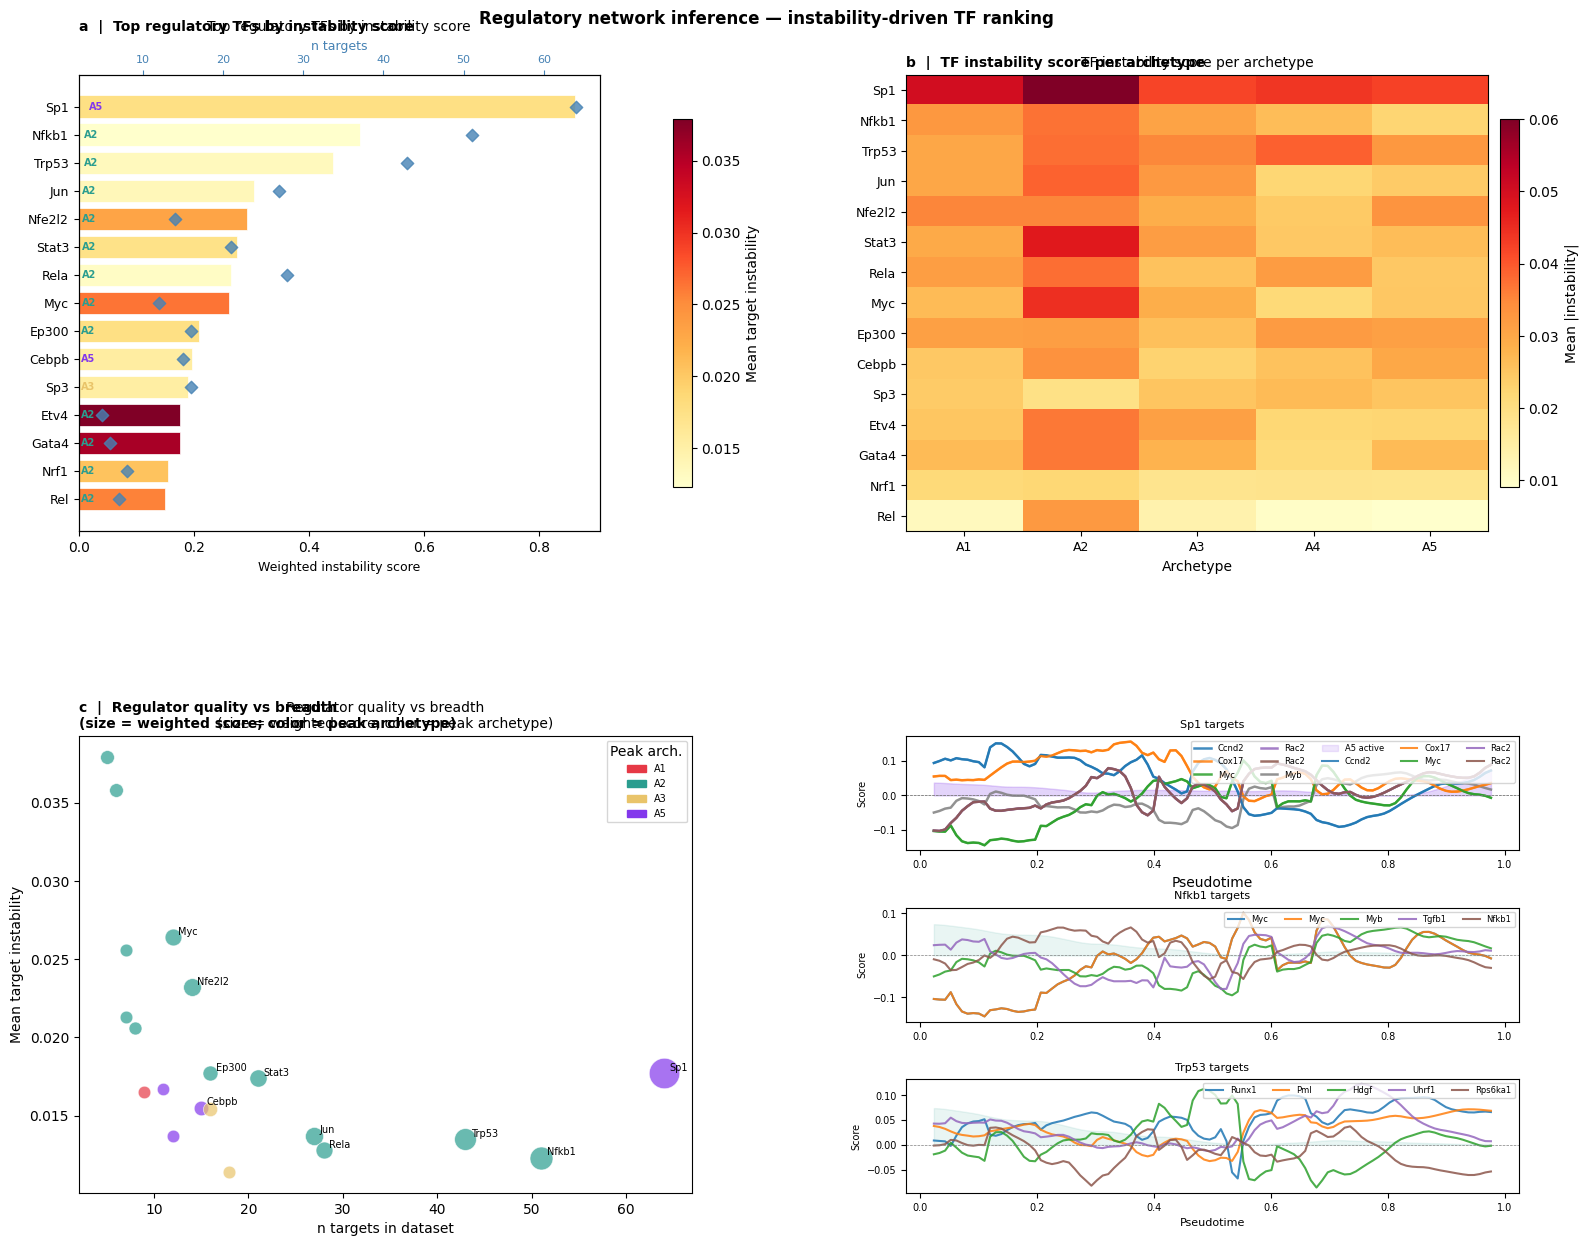

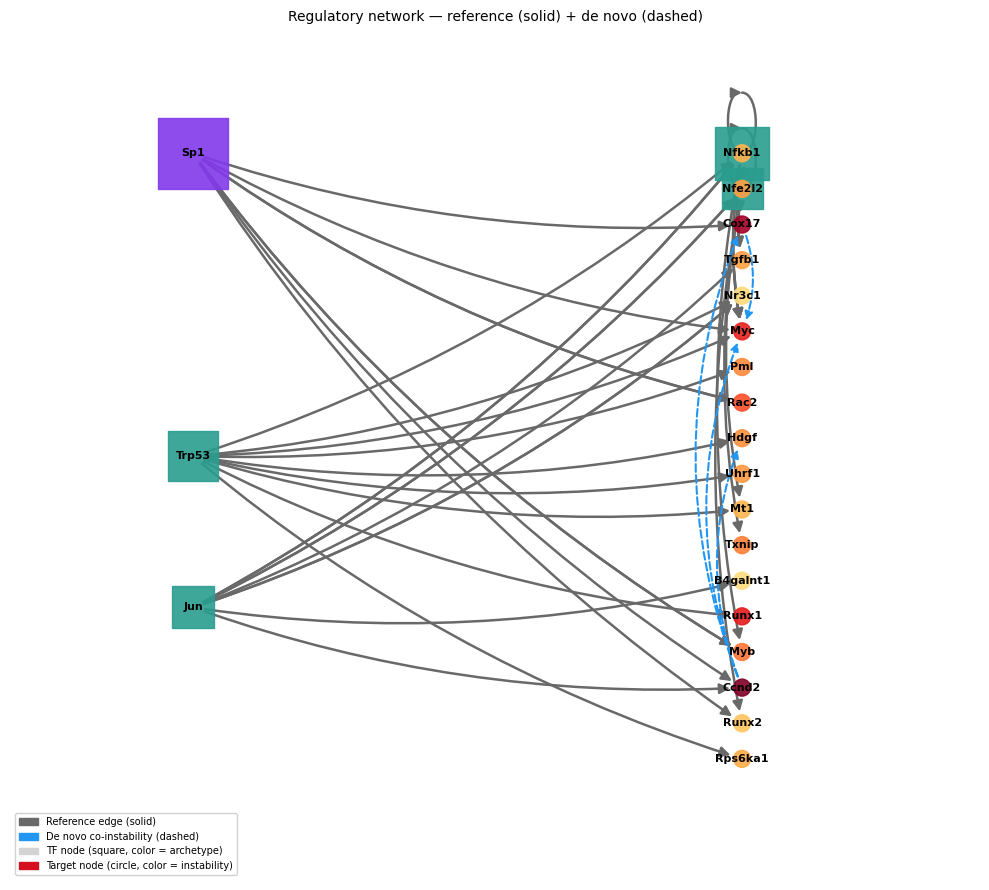

<Axes: title={'center': 'Regulatory network — reference (solid) + de novo (dashed)'}>

In [36]:
# Four-panel summary (bar + heatmap + scatter + profiles)
sjd.pl.regulator_summary(adata, save=OUTDIR + 'regulator_summary.pdf')

# Hybrid network graph (solid = reference, dashed = de novo co-instability)
sjd.pl.regulator_network(
    adata,
    n_tfs     = 5,
    n_targets = 6,
    n_denovo  = 4,
    save      = OUTDIR + 'regulator_network.pdf',
)

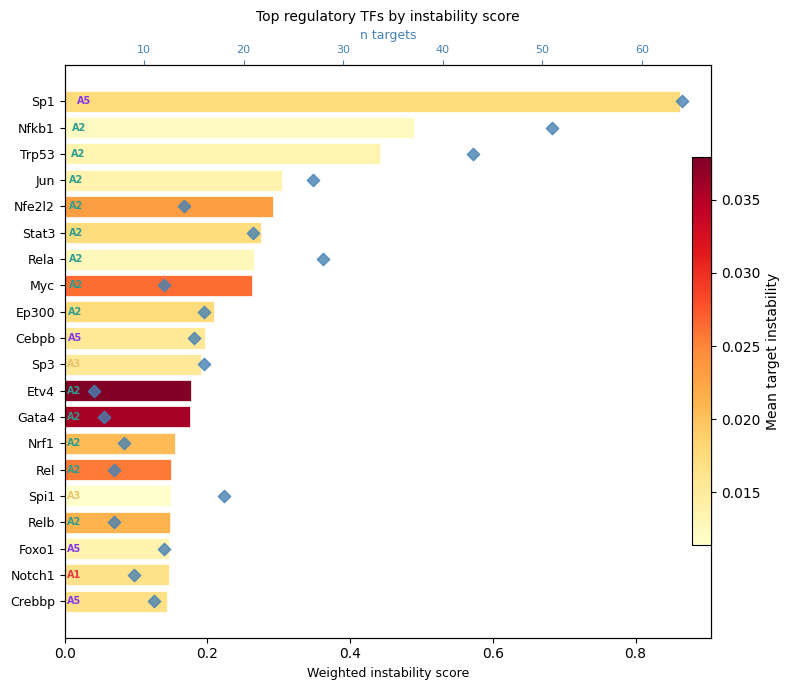

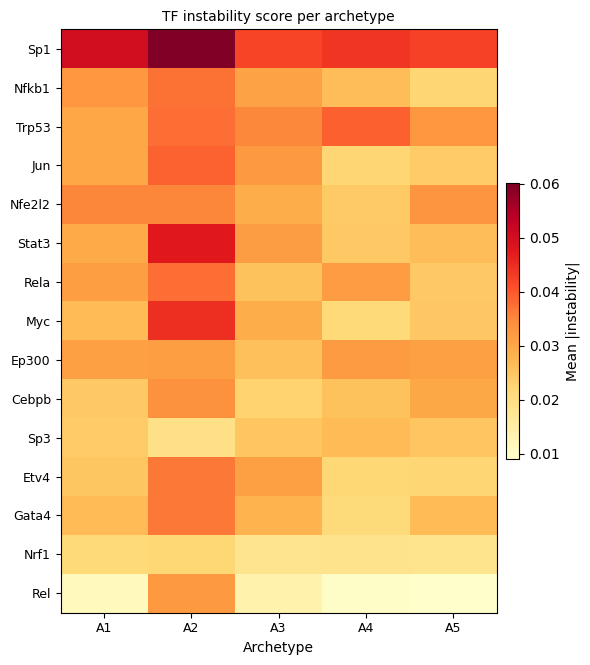

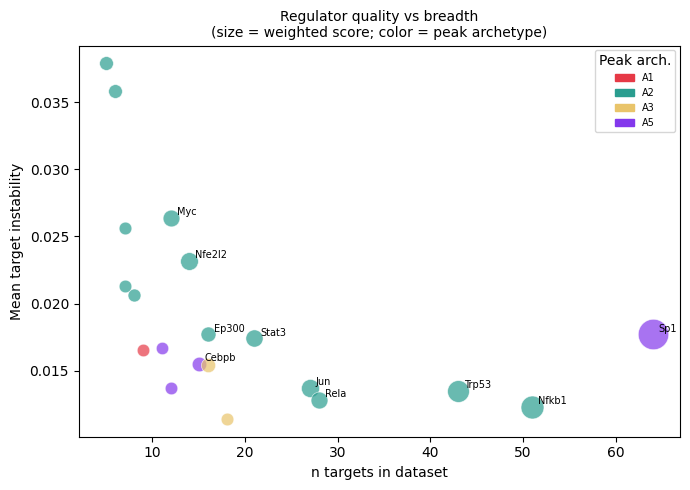

/Users/terooatt/Downloads/scJDO/scjdo/pl/_regulators.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


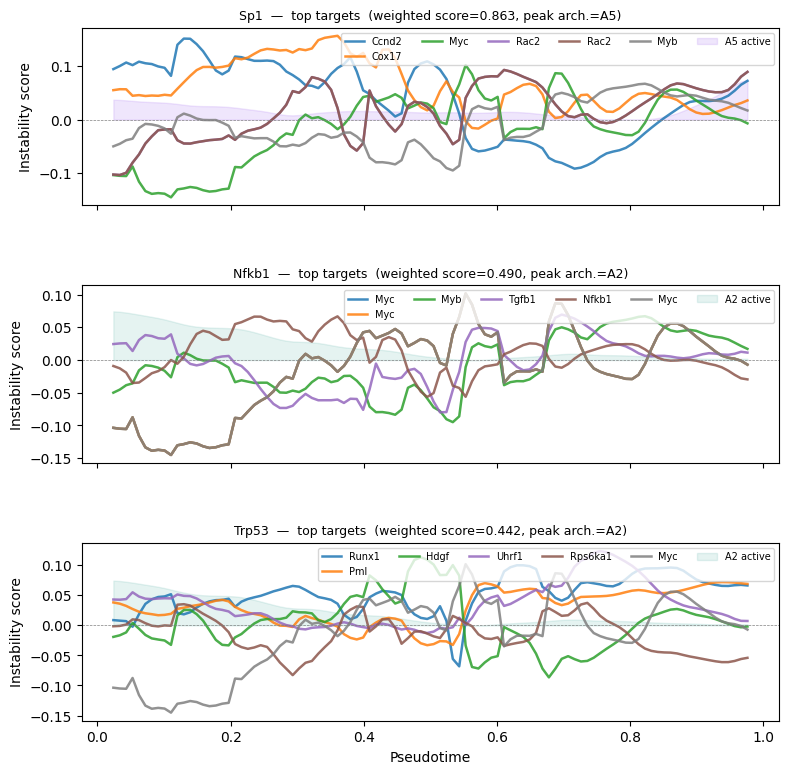

array([<Axes: title={'center': 'Sp1  —  top targets  (weighted score=0.863, peak arch.=A5)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Nfkb1  —  top targets  (weighted score=0.490, peak arch.=A2)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Trp53  —  top targets  (weighted score=0.442, peak arch.=A2)'}, xlabel='Pseudotime', ylabel='Instability score'>],
      dtype=object)

In [37]:
# Individual panels
sjd.pl.regulator_barplot(adata, n_show=20, save=OUTDIR + 'reg_barplot.pdf')
sjd.pl.regulator_heatmap(adata, n_show=15, save=OUTDIR + 'reg_heatmap.pdf')
sjd.pl.regulator_scatter(adata, n_label=10, save=OUTDIR + 'reg_scatter.pdf')
sjd.pl.regulator_profiles(adata, n_tfs=3,  save=OUTDIR + 'reg_profiles.pdf')